Fetching India EPU dataset...
--> Saved PNG image to 'india-epu.png'
--> Saved interactive HTML to 'india-epu.html'


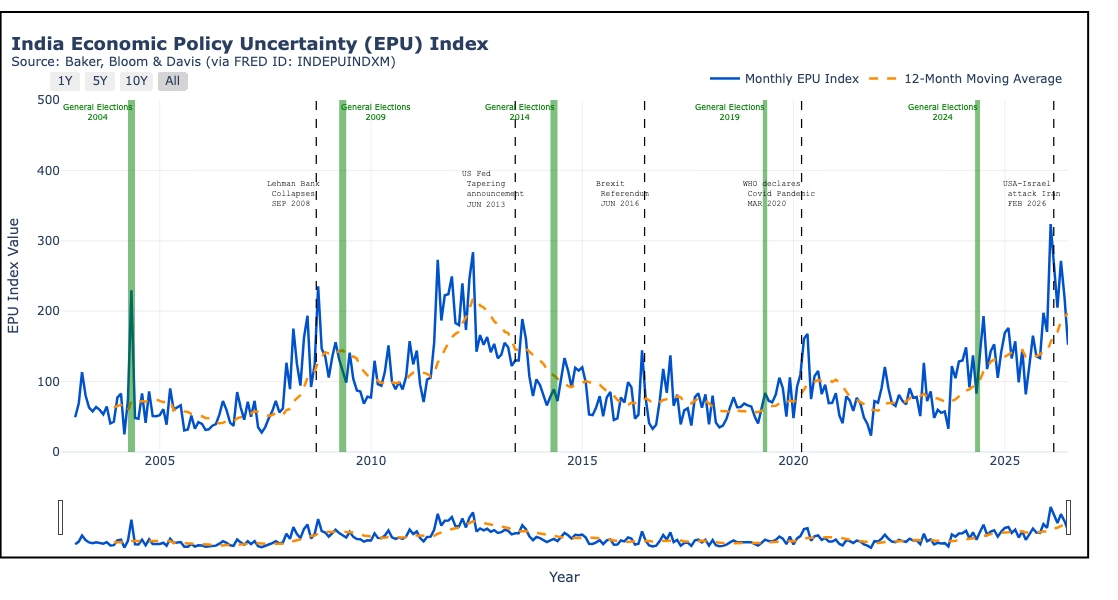

In [31]:
"""
===============================================================================
SCRIPT NAME    : India Economic Policy Uncertainty (EPU) Index Visualizer
PURPOSE        : Fetches, cleans, and plots India's EPU dataset from FRED, 
                 annotating key general elections and major economic/geopolitical
                 shocks over time using Plotly.
===============================================================================

PREREQUISITES
-------------
1. Python Version: Python 3.8 or higher.
2. Active Internet Connection: Required to download live CSV data from FRED.
3. Required Python Packages:
   - pandas   : Data fetching, cleaning, and moving average calculations.
   - plotly   : Generating interactive charts and layout styling.
   - kaleido  : Backend engine required for exporting static image formats (PNG).

   Installation Command:
   $ pip install pandas plotly kaleido

INPUT
-----
- Live Data Source : Federal Reserve Economic Data (FRED)
- Data Endpoint    : https://fred.stlouisfed.org/graph/fredgraph.csv?id=INDEPUINDXM
- Data Series ID   : INDEPUINDXM (Economic Policy Uncertainty Index for India 
                     by Baker, Bloom, and Davis)

PROCESSING LOGIC
----------------
1. Ingestion & Preprocessing:
   - Reads CSV directly from FRED endpoint into a Pandas DataFrame.
   - Converts raw strings to numeric values (`pd.to_numeric`), converting missing 
     value placeholders (e.g., '.') to NaN.
   - Parses dates into datetime format and removes missing observations.
2. Feature Engineering:
   - Calculates a 12-Month Rolling Moving Average (`12M_Moving_Avg`) to smooth 
     out high-frequency noise and highlight macro trends.
3. Visualization & Annotations (Plotly):
   - Plots time-series traces for Monthly EPU and 12-Month Moving Average.
   - Overlays shaded vertical bands (`add_vrect`) for Indian General Election 
     windows (2004, 2009, 2014, 2019, 2024).
   - Adds vertical milestone markers (`add_vline`) and callouts (`add_annotation`) 
     for key shocks (Lehman Collapse, Fed Tapering, Brexit, COVID-19, 2026 Conflict).
   - Layout Configuration: Sets `range=[0, 500]` on the Y-axis for stark visual 
     contrast, integrates range-sliders, quick-zoom buttons (1Y, 5Y, 10Y, All), 
     and unified hover tooltips.

OUTPUT
------
1. Static Image    : 'india_epu.png' (High-resolution PNG saved via Kaleido)
2. Interactive Web : 'india_epu.html' (Standalone interactive HTML file)
3. Direct Render   : Interactive chart render in browser/Jupyter via `fig.show()`
===============================================================================
"""
import pandas as pd
import plotly.graph_objects as go

# 1. Fetch live India EPU data directly from FRED
FRED_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=INDEPUINDXM"

print("Fetching India EPU dataset...")
df = pd.read_csv(FRED_URL)

# 2. Data Cleaning and Preprocessing
df.columns = ["Date", "EPU_Index"]

# Convert 'EPU_Index' to numeric (FRED uses '.' for missing entries)
df["EPU_Index"] = pd.to_numeric(df["EPU_Index"], errors="coerce")

# Convert 'Date' to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Drop missing values
df = df.dropna(subset=["EPU_Index"]).reset_index(drop=True)

# Calculate a 12-month Moving Average
df["12M_Moving_Avg"] = df["EPU_Index"].rolling(window=12).mean()

# 3. Build Interactive Visualization with Plotly
fig = go.Figure()

# Add Monthly EPU Line
fig.add_trace(
    go.Scatter(
        x=df["Date"],
        y=df["EPU_Index"],
        mode="lines",
        name="Monthly EPU Index",
        line=dict(color="#0052CC", width=2.5),
        hovertemplate="<b>Date:</b> %{x|%B %Y}<br><b>EPU Index:</b> %{y:.2f}<extra></extra>",
    )
)

# Add 12-Month Moving Average Line
fig.add_trace(
    go.Scatter(
        x=df["Date"],
        y=df["12M_Moving_Avg"],
        mode="lines",
        name="12-Month Moving Average",
        line=dict(color="#FF8C00", width=2.5, dash="dash"),
        hovertemplate="<b>Date:</b> %{x|%B %Y}<br><b>12M Average:</b> %{y:.2f}<extra></extra>",
    )
)

# Timeline of important events (Elections)
fig.add_vrect(
    x0="2004-04-01",
    x1="2004-06-01",
    annotation_text="General Elections<br>2004",
    annotation_position="top right",
    annotation_font_size=8,
    annotation_font_color="Green",
    fillcolor="green",
    opacity=0.5,
    line_width=0,
)
fig.add_vrect(
    x0="2009-04-01",
    x1="2009-06-01",
    annotation_text="General Elections<br>2009",
    annotation_position="top left",
    annotation_font_size=8,
    annotation_font_color="Green",
    fillcolor="green",
    opacity=0.5,
    line_width=0,
)
fig.add_vrect(
    x0="2014-04-01",
    x1="2014-06-01",
    annotation_text="General Elections<br>2014",
    annotation_position="top right",
    annotation_font_size=8,
    annotation_font_color="Green",
    fillcolor="Green",
    opacity=0.5,
    line_width=0,
)
fig.add_vrect(
    x0="2019-04-11",
    x1="2019-05-19",
    annotation_text="General Elections<br>2019",
    annotation_position="top right",
    annotation_font_size=8,
    annotation_font_color="Green",
    fillcolor="Green",
    opacity=0.5,
    line_width=0,
)
fig.add_vrect(
    x0="2024-04-19",
    x1="2024-06-01",
    annotation_text="General Elections<br>2024",
    annotation_position="top right",
    annotation_font_size=8,
    annotation_font_color="Green",
    fillcolor="Green",
    opacity=0.5,
    line_width=0,
)

# Wars and Economic Shocks
fig.add_vline(
    x="2008-09-15",
    line_width=1.25,
    line_dash="dash",
    line_color="Black",
)
fig.add_annotation(
    x="2008-09-15",
    y=350,
    text="Lehman Bank <br> Collapses <br> SEP 2008",
    yanchor="bottom",
    showarrow=True,
    arrowhead=1,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor="#636363",
    ax=-20,
    ay=5,
    font=dict(size=8, color="Black", family="Courier New, monospace"),
    align="left",
)

fig.add_vline(
    x="2013-06-01",
    line_width=1.25,
    line_dash="dash",
    line_color="Black",
)
fig.add_annotation(
    x="2013-06-01",
    y=350,
    text="US Fed <br> Tapering <br> announcement <br> JUN 2013",
    yanchor="bottom",
    showarrow=True,
    arrowhead=1,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor="#636363",
    ax=-20,
    ay=5,
    font=dict(size=8, color="Black", family="Courier New, monospace"),
    align="left",
)

fig.add_vline(
    x="2016-06-23",
    line_width=1.25,
    line_dash="dash",
    line_color="Black",
)
fig.add_annotation(
    x="2016-06-23",
    y=350,
    text="Brexit <br> Referendum <br> JUN 2016",
    yanchor="bottom",
    showarrow=True,
    arrowhead=1,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor="#636363",
    ax=-20,
    ay=5,
    font=dict(size=8, color="Black", family="Courier New, monospace"),
    align="left",
)

fig.add_vline(
    x="2020-03-11",
    line_width=1.25,
    line_dash="dash",
    line_color="Black",
)
fig.add_annotation(
    x="2020-03-11",
    y=350,
    text="WHO declares <br> Covid Pandemic <br> MAR 2020",
    yanchor="bottom",
    showarrow=True,
    arrowhead=1,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor="#636363",
    ax=-20,
    ay=5,
    font=dict(size=8, color="Black", family="Courier New, monospace"),
    align="left",
)

fig.add_vline(
    x="2026-02-28",
    line_width=1.25,
    line_dash="dash",
    line_color="Black",
)
fig.add_annotation(
    x="2026-02-28",
    y=350,
    text="USA-Israel <br> attack Iran <br> FEB 2026",
    yanchor="bottom",
    showarrow=True,
    arrowhead=1,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor="#636363",
    ax=-20,
    ay=5,
    font=dict(size=8, color="Black", family="Courier New, monospace"),
    align="left",
)

# 3.B Add a full canvas border shape
fig.add_shape(type="rect",
    xref="paper", yref="paper",
    x0=-0.06, y0=-0.3, x1=1.02, y1=1.25, 
    line=dict(
        #color="RoyalBlue",
        color="black", #named colors from https://stackoverflow.com/a/72502441/8508004
        width=2,
    ),
    #fillcolor="LightSkyBlue",
)

# 4. Enhance Layout & Interactivity
fig.update_layout(
    height=600,
    width=1000,
    title=dict(
        text="<b>India Economic Policy Uncertainty (EPU) Index</b><br>"
        "<sup>Source: Baker, Bloom & Davis (via FRED ID: INDEPUINDXM)</sup>",
        x=0.01,
        font=dict(size=18),
    ),
    xaxis=dict(
        title="Year",
        type="date",
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1Y", step="year", stepmode="backward"),
                dict(count=5, label="5Y", step="year", stepmode="backward"),
                dict(count=10, label="10Y", step="year", stepmode="backward"),
                dict(step="all", label="All"),
            ])
        ),
        rangeslider=dict(visible=True),
    ),
    yaxis=dict(
        title="EPU Index Value",
        range=[0, 500],  # Restricts the y-axis maximum to 500
        gridcolor="rgba(220, 220, 220, 0.5)",
    ),
    template="plotly_white",
    hovermode="x unified",
    legend=dict(
        orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1
    ),
    margin=dict(l=50, r=50, t=100, b=50),
)


# Output filenames
output_png = "india-epu.png"
output_html = "india-epu.html"

# 1. Save static PNG image
fig.write_image(output_png, width=1200, height=700, scale=2)
print(f"--> Saved PNG image to '{output_png}'")

# 2. Get the figure HTML component string
# Note: full_html=False prevents it from generating <html> and <body> tags yet
fig_html = fig.to_html(full_html=False, include_plotlyjs='cdn')

# 3. Wrap it in a CSS flexbox container
centered_html = f"""
<!DOCTYPE html>
<html>
<head>
    <title>Centered Plotly Figure</title>
</head>
<body>
    <div style="display: flex; justify-content: center; align-items: center; min-height: 100vh;">
        <div style="width: 90%; max-width: 900px; max-height: 800px;">
            {fig_html}
        </div>
    </div>
</body>
</html>
"""

# 4. Save to an HTML file
with open(output_html, "w", encoding="utf-8") as f:
    f.write(centered_html)
    
    # # 2. Save interactive HTML file
    # fig.write_html(output_html)
    print(f"--> Saved interactive HTML to '{output_html}'")

# Render chart
fig.show()